In [1]:
import pandas as pd
import numpy as np
import streamlit as st
import joblib
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

import warnings
warnings.filterwarnings("ignore")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aruns\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aruns\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
df = pd.read_csv(rf"F:\siva\Data Science with genai\MLOPS\flipkart_sentiment_analysis\reviews_badminton\data.csv")

In [3]:
df.head()

,Reviewer Name,Review Title,Place of Review,Up Votes,Down Votes,Month,Review text,Ratings
0,Kamal Suresh,Nice product,"Certified Buyer, Chirakkal",889.0,64.0,Feb 2021,"Nice product, good quality, but price is now r...",4
1,Flipkart Customer,Don't waste your money,"Certified Buyer, Hyderabad",109.0,6.0,Feb 2021,They didn't supplied Yonex Mavis 350. Outside ...,1
2,A. S. Raja Srinivasan,Did not meet expectations,"Certified Buyer, Dharmapuri",42.0,3.0,Apr 2021,Worst product. Damaged shuttlecocks packed in ...,1
3,Suresh Narayanasamy,Fair,"Certified Buyer, Chennai",25.0,1.0,NaN,"Quite O. K. , but nowadays the quality of the...",3
4,ASHIK P A,Over priced,NaN,147.0,24.0,Apr 2016,Over pricedJust â?¹620 ..from retailer.I didn'...,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8518 entries, 0 to 8517
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Reviewer Name    8508 non-null   object 
 1   Review Title     8508 non-null   object 
 2   Place of Review  8468 non-null   object 
 3   Up Votes         8508 non-null   float64
 4   Down Votes       8508 non-null   float64
 5   Month            8053 non-null   object 
 6   Review text      8510 non-null   object 
 7   Ratings          8518 non-null   int64  
dtypes: float64(2), int64(1), object(5)
memory usage: 532.5+ KB


In [5]:
df = df[['Review text', 'Ratings']]
df.rename(columns={'Review text': 'review'}, inplace=True)

In [6]:
df['review'].isna().sum()

8

In [7]:
df.dropna(subset=['review'], inplace=True)

In [8]:
df = df[df['Ratings'] != 3]

df['sentiment'] = df['Ratings'].apply(
    lambda x: 1 if x >= 4 else 0
)

In [9]:
df['sentiment'].value_counts()

sentiment
1    6823
0    1072
Name: count, dtype: int64

In [10]:
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    return ' '.join(words)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aruns\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aruns\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [11]:
df['clean_review'] = df['review'].apply(clean_text)

In [12]:
df['clean_review']

0       nice product good quality price rising bad sig...
1       supplied yonex mavis outside cover yonex ad in...
2       worst product damaged shuttlecock packed new b...
4       pricedjust retailer understand wat advantage b...
5                good quality product delivered time read
                              ...                        
8504                   received product intact sealedread
8506                mark available market less price read
8507                              nice delivery speedread
8508    complaint item best one way priced easily avai...
8509    sure charged product mrp okay pay r product co...
Name: clean_review, Length: 7895, dtype: object

In [13]:
from sklearn.model_selection import train_test_split

X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [16]:
from sklearn.metrics import f1_score, classification_report

y_pred = model.predict(X_test_tfidf)

print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

F1 Score: 0.9534966276180333
              precision    recall  f1-score   support

           0       0.83      0.49      0.62       214
           1       0.92      0.98      0.95      1365

    accuracy                           0.92      1579
   macro avg       0.88      0.74      0.78      1579
weighted avg       0.91      0.92      0.91      1579



In [17]:
import joblib

joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [18]:
joblib.dump(model, "sentiment_model.pkl")

['sentiment_model.pkl']

In [19]:
def predict_sentiment(review):
    review = clean_text(review)
    vector = tfidf.transform([review])
    prediction = model.predict(vector)[0]
    return "Positive" if prediction == 1 else "Negative"

predict_sentiment("The shuttle breaks very fast and quality is poor")

'Negative'

In [20]:
# Filter negative reviews
negative_reviews = df[df['sentiment'] == 0]

negative_reviews[['review']].head()

,review
1,They didn't supplied Yonex Mavis 350. Outside ...
2,Worst product. Damaged shuttlecocks packed in ...
4,Over pricedJust â?¹620 ..from retailer.I didn'...
13,This is the second time i am getting an opened...
16,I usually buy them the same model but this did...


In [21]:
from collections import Counter

all_words = ' '.join(negative_reviews['clean_review']).split()
word_freq = Counter(all_words)

word_freq.most_common(20)

[('read', 328),
 ('shuttle', 318),
 ('quality', 292),
 ('product', 247),
 ('bad', 193),
 ('good', 132),
 ('worst', 106),
 ('poor', 97),
 ('qualityread', 94),
 ('one', 80),
 ('goodread', 77),
 ('day', 73),
 ('buy', 67),
 ('productread', 63),
 ('box', 59),
 ('cork', 54),
 ('mavis', 52),
 ('time', 51),
 ('flipkart', 50),
 ('got', 47)]

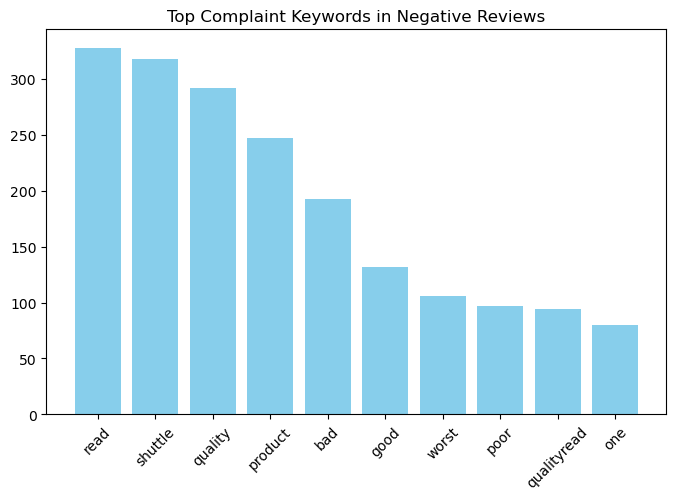

In [22]:
%matplotlib inline
import matplotlib.pyplot as plt

common_words = word_freq.most_common(10)
words, counts = zip(*common_words)

plt.figure(figsize=(8,5))
plt.bar(words, counts, color='skyblue')
plt.xticks(rotation=45)
plt.title("Top Complaint Keywords in Negative Reviews")
plt.show()

In [23]:
st.subheader("Product: YONEX MAVIS 350 Nylon Shuttle")

2026-04-03 19:28:21.232 
  command:

    streamlit run C:\ProgramData\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]


DeltaGenerator()

In [24]:
st.subheader("Product: YONEX MAVIS 350 Nylon Shuttle")

DeltaGenerator()

In [25]:
st.caption("Model: TF-IDF + Logistic Regression | Metric: F1-Score")

DeltaGenerator()

In [26]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    return ' '.join(words)

In [27]:
review = "Shuttle breaks very fast and quality is very poor"

In [28]:
cleaned_review = clean_text(review)
vector = tfidf.transform([cleaned_review])

In [29]:
prediction = model.predict(vector)[0]

In [30]:
probabilities = model.predict_proba(vector)[0]

In [31]:
probabilities

array([0.87788073, 0.12211927])

In [32]:
prediction

0

In [33]:
sentiment = "Positive" if prediction == 1 else "Negative"
confidence = round(max(probabilities) * 100, 2)

In [34]:
print("Review:", review)
print("Predicted Sentiment:", sentiment)
print("Confidence Score:", confidence, "%")

Review: Shuttle breaks very fast and quality is very poor
Predicted Sentiment: Negative
Confidence Score: 87.79 %


In [35]:
import joblib
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

model = joblib.load("sentiment_model.pkl")
tfidf = joblib.load("tfidf_vectorizer.pkl")

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    words = text.split()
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]
    return ' '.join(words)

review = "Shuttle breaks very fast and quality is very poor"

cleaned_review = clean_text(review)
vector = tfidf.transform([cleaned_review])

prediction = model.predict(vector)[0]
probabilities = model.predict_proba(vector)[0]

sentiment = "Positive" if prediction == 1 else "Negative"
confidence = round(max(probabilities) * 100, 2)

print("Review:", review)
print("Predicted Sentiment:", sentiment)
print("Confidence Score:", confidence, "%")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aruns\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\aruns\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Review: Shuttle breaks very fast and quality is very poor
Predicted Sentiment: Negative
Confidence Score: 87.79 %


In [36]:
negative_df = df[df['sentiment'] == 0]
negative_df.head()

,review,Ratings,sentiment,clean_review
1,They didn't supplied Yonex Mavis 350. Outside ...,1,0,supplied yonex mavis outside cover yonex ad in...
2,Worst product. Damaged shuttlecocks packed in ...,1,0,worst product damaged shuttlecock packed new b...
4,Over pricedJust â?¹620 ..from retailer.I didn'...,1,0,pricedjust retailer understand wat advantage b...
13,This is the second time i am getting an opened...,1,0,second time getting opened bundle yonex mavis ...
16,I usually buy them the same model but this did...,1,0,usually buy model last even dayread


In [37]:
all_negative_text = " ".join(negative_df['clean_review'])

In [38]:
from collections import Counter

words = all_negative_text.split()
word_freq = Counter(words)

word_freq.most_common(20)

[('read', 328),
 ('shuttle', 318),
 ('quality', 292),
 ('product', 247),
 ('bad', 193),
 ('good', 132),
 ('worst', 106),
 ('poor', 97),
 ('qualityread', 94),
 ('one', 80),
 ('goodread', 77),
 ('day', 73),
 ('buy', 67),
 ('productread', 63),
 ('box', 59),
 ('cork', 54),
 ('mavis', 52),
 ('time', 51),
 ('flipkart', 50),
 ('got', 47)]

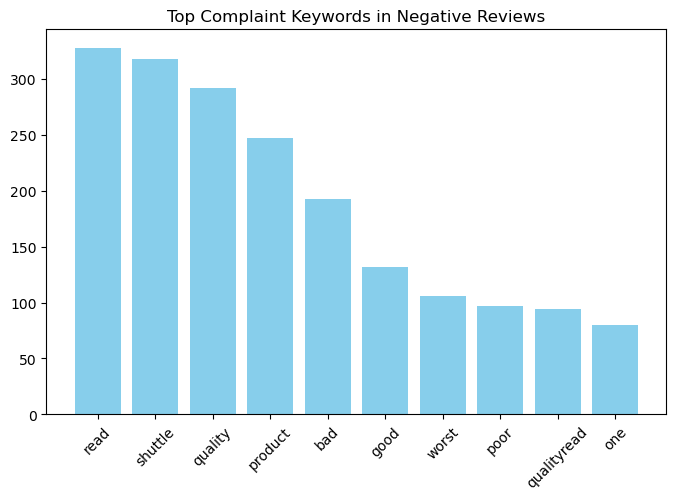

In [39]:
%matplotlib inline
import matplotlib.pyplot as plt

common_words = word_freq.most_common(10)
words, counts = zip(*common_words)

plt.figure(figsize=(8,5))
plt.bar(words, counts, color='skyblue')
plt.xticks(rotation=45)
plt.title("Top Complaint Keywords in Negative Reviews")
plt.show()